# **1. Perkenalan Dataset**


Tahap pertama, Anda harus mencari dan menggunakan dataset dengan ketentuan sebagai berikut:

1. **Sumber Dataset**:  
   Dataset dapat diperoleh dari berbagai sumber, seperti public repositories (*Kaggle*, *UCI ML Repository*, *Open Data*) atau data primer yang Anda kumpulkan sendiri.


# **2. Import Library**

Pada tahap ini, Anda perlu mengimpor beberapa pustaka (library) Python yang dibutuhkan untuk analisis data dan pembangunan model machine learning atau deep learning.

In [1]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt
import seaborn as sns
import os

# **3. Memuat Dataset**

Pada tahap ini, Anda perlu memuat dataset ke dalam notebook. Jika dataset dalam format CSV, Anda bisa menggunakan pustaka pandas untuk membacanya. Pastikan untuk mengecek beberapa baris awal dataset untuk memahami strukturnya dan memastikan data telah dimuat dengan benar.

Jika dataset berada di Google Drive, pastikan Anda menghubungkan Google Drive ke Colab terlebih dahulu. Setelah dataset berhasil dimuat, langkah berikutnya adalah memeriksa kesesuaian data dan siap untuk dianalisis lebih lanjut.

Jika dataset berupa unstructured data, silakan sesuaikan dengan format seperti kelas Machine Learning Pengembangan atau Machine Learning Terapan

In [2]:
df = pd.read_csv('mobile_price_cls_raw/mobile_price_cls_train.csv')
print(f"Dataset berhasil dimuat. Total data: {df.shape[0]} baris, {df.shape[1]} kolom.")

df.head()

Dataset berhasil dimuat. Total data: 2000 baris, 21 kolom.


,battery_power,blue,clock_speed,dual_sim,fc,four_g,int_memory,m_dep,mobile_wt,n_cores,...,px_height,px_width,ram,sc_h,sc_w,talk_time,three_g,touch_screen,wifi,price_range
0,842,0,2.2,0,1,0,7,0.6,188,2,...,20,756,2549,9,7,19,0,0,1,1
1,1021,1,0.5,1,0,1,53,0.7,136,3,...,905,1988,2631,17,3,7,1,1,0,2
2,563,1,0.5,1,2,1,41,0.9,145,5,...,1263,1716,2603,11,2,9,1,1,0,2
3,615,1,2.5,0,0,0,10,0.8,131,6,...,1216,1786,2769,16,8,11,1,0,0,2
4,1821,1,1.2,0,13,1,44,0.6,141,2,...,1208,1212,1411,8,2,15,1,1,0,1


# **4. Exploratory Data Analysis (EDA)**

Pada tahap ini, Anda akan melakukan **Exploratory Data Analysis (EDA)** untuk memahami karakteristik dataset.

Tujuan dari EDA adalah untuk memperoleh wawasan awal yang mendalam mengenai data dan menentukan langkah selanjutnya dalam analisis atau pemodelan.

C:\Users\BKA\AppData\Local\Temp\ipykernel_28040\2484908754.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x='price_range', palette='viridis')


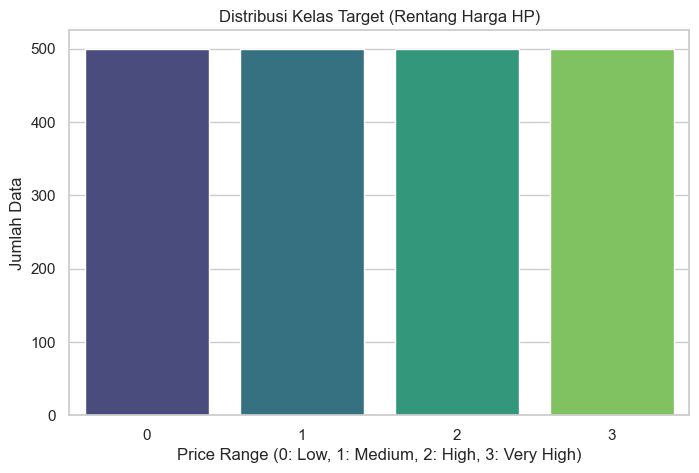

C:\Users\BKA\AppData\Local\Temp\ipykernel_28040\2484908754.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='price_range', y='ram', palette='Set2')


Insight: Distribusi target terlihat sangat seimbang (masing-masing 500 data). Ini sangat ideal untuk pelatihan model.



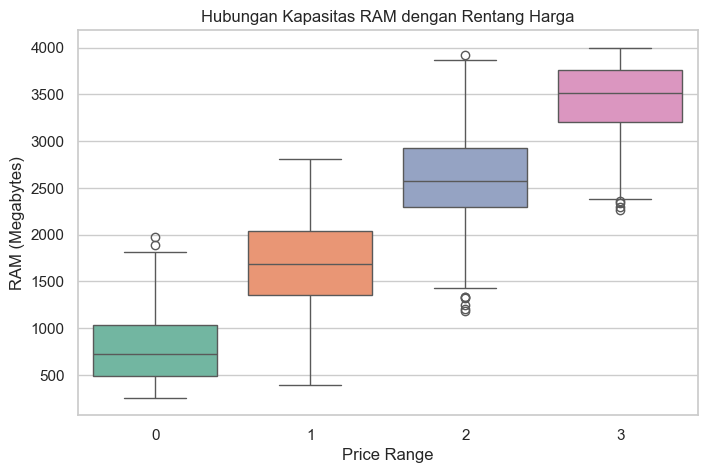

Insight: Terlihat jelas korelasi positif yang sangat kuat. Semakin tinggi rentang harga, semakin besar rata-rata kapasitas RAM yang tertanam.



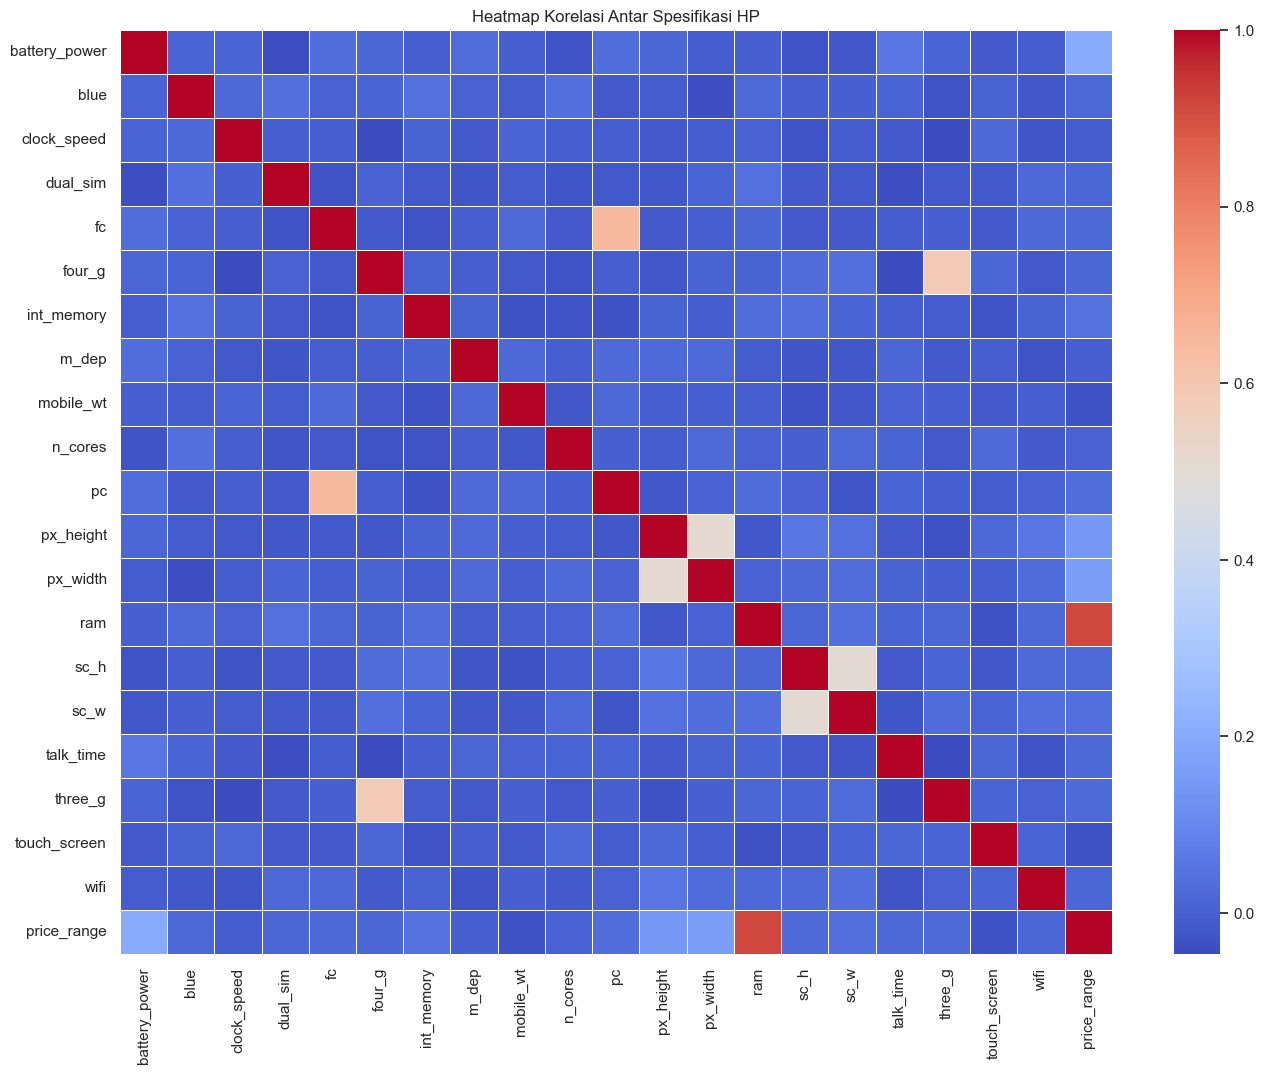

Insight: RAM memiliki warna paling pekat terhadap price_range. Selain itu, px_width dan px_height (resolusi layar) juga punya korelasi positif terhadap harga.


In [4]:
sns.set_theme(style="whitegrid")

# analisis univariat
plt.figure(figsize=(8, 5))
sns.countplot(data=df, x='price_range', palette='viridis')
plt.title('Distribusi Kelas Target (Rentang Harga HP)')
plt.xlabel('Price Range (0: Low, 1: Medium, 2: High, 3: Very High)')
plt.ylabel('Jumlah Data')
plt.show()
print("Insight: Distribusi target terlihat sangat seimbang (masing-masing 500 data). Ini sangat ideal untuk pelatihan model.\n")

# analisis bivariat/multivariat
plt.figure(figsize=(8, 5))
sns.boxplot(data=df, x='price_range', y='ram', palette='Set2')
plt.title('Hubungan Kapasitas RAM dengan Rentang Harga')
plt.xlabel('Price Range')
plt.ylabel('RAM (Megabytes)')
plt.show()
print("Insight: Terlihat jelas korelasi positif yang sangat kuat. Semakin tinggi rentang harga, semakin besar rata-rata kapasitas RAM yang tertanam.\n")

# analisis korelasi
plt.figure(figsize=(16, 12))
sns.heatmap(df.corr(), cmap='coolwarm', fmt=".2f", linewidths=0.5)
plt.title('Heatmap Korelasi Antar Spesifikasi HP')
plt.show()
print("Insight: RAM memiliki warna paling pekat terhadap price_range. Selain itu, px_width dan px_height (resolusi layar) juga punya korelasi positif terhadap harga.")

# **5. Data Preprocessing**

Pada tahap ini, data preprocessing adalah langkah penting untuk memastikan kualitas data sebelum digunakan dalam model machine learning.

Jika Anda menggunakan data teks, data mentah sering kali mengandung nilai kosong, duplikasi, atau rentang nilai yang tidak konsisten, yang dapat memengaruhi kinerja model. Oleh karena itu, proses ini bertujuan untuk membersihkan dan mempersiapkan data agar analisis berjalan optimal.

Berikut adalah tahapan-tahapan yang bisa dilakukan, tetapi **tidak terbatas** pada:
1. Menghapus atau Menangani Data Kosong (Missing Values)
2. Menghapus Data Duplikat
3. Normalisasi atau Standarisasi Fitur
4. Deteksi dan Penanganan Outlier
5. Encoding Data Kategorikal
6. Binning (Pengelompokan Data)

Cukup sesuaikan dengan karakteristik data yang kamu gunakan yah. Khususnya ketika kami menggunakan data tidak terstruktur.

In [6]:
# missing value
print("Jumlah missing value:")
print(df.isnull().sum())
df = df.dropna()

# duplikat
print(f"\nJumlah data duplikat sebelum dihapus: {df.duplicated().sum()}")
df = df.drop_duplicates()
print(f"Total baris data setelah pembersihan: {df.shape[0]} baris\n")

# split & scaling
X = df.drop(columns=['price_range'])
y = df['price_range']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

scaler = StandardScaler()
X_train_scaled = pd.DataFrame(scaler.fit_transform(X_train), columns=X_train.columns)
X_test_scaled = pd.DataFrame(scaler.transform(X_test), columns=X_test.columns)

y_train_df = pd.DataFrame(y_train, columns=['price_range'])
y_test_df = pd.DataFrame(y_test, columns=['price_range'])

os.makedirs('mobile_price_cls_preprocessing', exist_ok=True)
X_train_scaled.to_csv('mobile_price_cls_preprocessing/X_train.csv', index=False)
X_test_scaled.to_csv('mobile_price_cls_preprocessing/X_test.csv', index=False)
y_train_df.to_csv('mobile_price_cls_preprocessing/y_train.csv', index=False)
y_test_df.to_csv('mobile_price_cls_preprocessing/y_test.csv', index=False)

print("Preprocessing selesai! Data bersih tersimpan di folder 'mobile_price_cls_preprocessing'.")

Jumlah missing value:
battery_power    0
blue             0
clock_speed      0
dual_sim         0
fc               0
four_g           0
int_memory       0
m_dep            0
mobile_wt        0
n_cores          0
pc               0
px_height        0
px_width         0
ram              0
sc_h             0
sc_w             0
talk_time        0
three_g          0
touch_screen     0
wifi             0
price_range      0
dtype: int64

Jumlah data duplikat sebelum dihapus: 0
Total baris data setelah pembersihan: 2000 baris

Preprocessing selesai! Data bersih tersimpan di folder 'mobile_price_cls_preprocessing'.
